# ML1 (2026) Task 2 — Developer Salary Prediction

**Target:** push internal test RMSE below ~33,000 USD.

### Strategy changes vs prior submission
1. **Cleaner R17 handling.** Drop R17 rows with salary < \$500 from *training only* (≈70 rows, almost certainly currency-mixed); keep validation/test natural. No upper-tail winsorisation — that was capping our top-end predictions.
2. **Richer feature engineering.** `dev.role` keyword flags (Senior / Lead / Manager / Junior / Principal / Architect), experience interactions and quadratic terms, total technology-breadth, AI-usage flag, ratio features.
3. **Wider SVR hyperparameter grid.** Old grid `C ∈ [0.1, 0.2, 0.5]` was too restrictive — too smooth → bias toward median → undershoots high earners.
4. **Duan's smearing back-transform**, calibrated on *validation residuals* (not training), only adopted if it improves val RMSE on the raw dollar scale.
5. **Linear ensemble** of the two best models (SVR RBF + ElasticNet) — within the ML1 toolkit. Weights learned on the held-out validation set.

### Methods used (all from the ML1 syllabus)
OLS, Ridge, LASSO, Elastic Net, KNN, SVR (RBF kernel).


In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# 1. IMPORTS
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

SEED      = 42
TARGET    = "annual.pay.usd"
ID_COL    = "id"
MULTI_SEP = ";"

print("Imports OK")

Imports OK


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# 2. DATA LOADING
# ──────────────────────────────────────────────────────────────────────────────
df_raw     = pd.read_csv("train.csv")
kaggle_raw = pd.read_csv("test.csv")

print(f"Train shape : {df_raw.shape}")
print(f"Test shape  : {kaggle_raw.shape}")
print(f"\nTarget — raw: min=${df_raw[TARGET].min():,.0f}  median=${df_raw[TARGET].median():,.0f}  "
      f"mean=${df_raw[TARGET].mean():,.0f}  max=${df_raw[TARGET].max():,.0f}")
print(f"Target — raw skewness : {df_raw[TARGET].skew():.2f}")
print(f"Target — log skewness : {np.log(df_raw[TARGET].clip(lower=1)).skew():.2f}")

# Column catalogue
NUMERIC_COLS = ["coding.years.total", "coding.years.professional",
                "experience.years", "job.satisfaction"]
ORDINAL_COLS = ["age.group", "education", "company.size",
                "tech.purchase.influence", "ai.sentiment", "ai.trust",
                "ai.complex.rating", "daily.search.time", "daily.answer.time"]
NOMINAL_COLS = ["region", "employment.type", "work.location",
                "is.dev.professional", "dev.role", "people.manager",
                "industry", "build.vs.buy", "cloud.hosting",
                "first.help.source", "uses.ai", "ai.job.threat"]
MULTISEL_COLS = ["side.coding", "how.learned.coding", "prog.languages",
                 "databases", "cloud.platforms", "web.frameworks",
                 "other.tech", "dev.tools", "dev.environments",
                 "personal.os", "work.os", "project.mgmt.tools",
                 "comm.tools", "ai.search.tools", "ai.tools.used"]

Train shape : (2512, 41)
Test shape  : (628, 41)

Target — raw: min=$1  median=$40,828  mean=$49,713  max=$4,773,360
Target — raw skewness : 33.13
Target — log skewness : -1.66


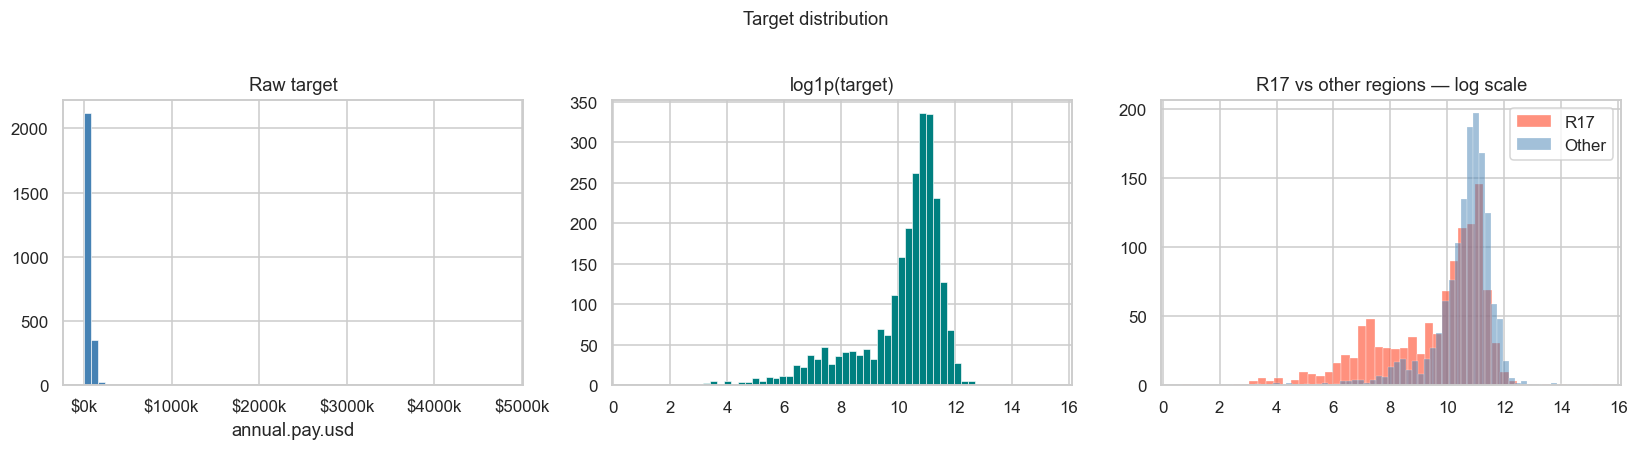


R17 rows with salary < $500 (likely local-currency reports): 71
R17 rows with salary < $1,000                                : 130


In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# 3. TARGET DISTRIBUTION + R17 ANOMALY
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_raw[TARGET], bins=60, color="steelblue", edgecolor="white", lw=0.4)
axes[0].set_title("Raw target")
axes[0].set_xlabel("annual.pay.usd")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))

axes[1].hist(np.log1p(df_raw[TARGET]), bins=60, color="teal", edgecolor="white", lw=0.4)
axes[1].set_title("log1p(target)")

# R17 vs others — log scale
r17_log    = np.log1p(df_raw.loc[df_raw["region"] == "R17", TARGET])
other_log  = np.log1p(df_raw.loc[df_raw["region"] != "R17", TARGET])
axes[2].hist(r17_log,   bins=50, alpha=0.7, color="tomato",    edgecolor="white", lw=0.3, label="R17")
axes[2].hist(other_log, bins=50, alpha=0.5, color="steelblue", edgecolor="white", lw=0.3, label="Other")
axes[2].set_title("R17 vs other regions — log scale")
axes[2].legend()

plt.suptitle("Target distribution", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Number of likely currency-mixed observations in R17
n_r17_low = ((df_raw["region"] == "R17") & (df_raw[TARGET] < 500)).sum()
print(f"\nR17 rows with salary < $500 (likely local-currency reports): {n_r17_low}")
print(f"R17 rows with salary < $1,000                                : "
      f"{((df_raw['region'] == 'R17') & (df_raw[TARGET] < 1000)).sum()}")

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# 4. SPLIT 70 / 15 / 15  — stratified on R17 membership
# ──────────────────────────────────────────────────────────────────────────────
df_raw = df_raw.copy()
df_raw["_r17_strat"] = np.where(df_raw["region"] == "R17", "R17", "Other")

train_df, temp_df = train_test_split(
    df_raw, test_size=0.30, random_state=SEED,
    stratify=df_raw["_r17_strat"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df["_r17_strat"]
)

for d in (train_df, val_df, test_df, df_raw):
    d.drop(columns=["_r17_strat"], inplace=True, errors="ignore")

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Initial split:  train={len(train_df):,}   val={len(val_df):,}   test={len(test_df):,}")

# ── Clean obvious currency-mixed observations from TRAINING ONLY ─────────────
# Rationale: R17 salaries < $500 are almost certainly local-currency reports
# (modal min annual dev salary in any currency at any country exceeds $500 USD-equivalent).
# We keep val/test untouched so our evaluation reflects real-world conditions.
MIN_SALARY_FLOOR = 500.0

mask_drop = (train_df["region"] == "R17") & (train_df[TARGET] < MIN_SALARY_FLOOR)
n_dropped = mask_drop.sum()
train_df = train_df.loc[~mask_drop].reset_index(drop=True)

print(f"Dropped {n_dropped} likely currency-mixed R17 rows from training only.")
print(f"Final split:    train={len(train_df):,}   val={len(val_df):,}   test={len(test_df):,}")

# ── Build the modelling target: log1p(target), no upper-tail winsorisation ───
# Floor salaries below $500 (very few cases in val/test if any) to avoid log(0).
def make_log_target(df):
    return np.log1p(df[TARGET].clip(lower=MIN_SALARY_FLOOR))

y_train = make_log_target(train_df).values
y_val   = make_log_target(val_df).values
y_test  = make_log_target(test_df).values

print(f"\ny_train — min: {y_train.min():.2f}   max: {y_train.max():.2f}   "
      f"mean: {y_train.mean():.2f}   std: {y_train.std():.2f}")
print(f"y_train skewness: {pd.Series(y_train).skew():.3f}   "
      f"(closer to 0 means closer to symmetric — desirable for regression)")

Initial split:  train=1,758   val=377   test=377
Dropped 49 likely currency-mixed R17 rows from training only.
Final split:    train=1,709   val=377   test=377

y_train — min: 6.22   max: 15.38   mean: 10.26   std: 1.31
y_train skewness: -1.203   (closer to 0 means closer to symmetric — desirable for regression)


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# 5. FEATURE ENGINEERING
# ──────────────────────────────────────────────────────────────────────────────
# Ordinal maps — using interval midpoints (better signal for distance-based & linear models)
ORDINAL_MAPS = {
    "age.group": {"18-24": 21, "25-34": 29.5, "35-44": 39.5, "45-54": 49.5, "55+": 60},
    "education": {
        "Primary/elementary school": 0,
        "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
        "Some college/university study without earning a degree": 2,
        "Associate degree (A.A., A.S., etc.)": 3,
        "Something else": 3,
        "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4,
        "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
        "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
    },
    "company.size": {
        "Just me - I am a freelancer, sole proprietor, etc.": 0,
        "2 to 9 employees": 1, "10 to 19 employees": 2,
        "20 to 99 employees": 3, "100 to 499 employees": 4,
        "500 to 999 employees": 5, "1,000 to 4,999 employees": 6,
        "5,000 to 9,999 employees": 7, "10,000 or more employees": 8,
    },
    "tech.purchase.influence": {
        "I have little or no influence": 0,
        "I have some influence": 1,
        "I have a great deal of influence": 2,
    },
    "ai.sentiment": {
        "Very unfavorable": 0, "Unfavorable": 1, "Indifferent": 2,
        "Unsure": 2, "Favorable": 3, "Very favorable": 4,
    },
    "ai.trust": {
        "Highly distrust": 0, "Somewhat distrust": 1,
        "Neither trust nor distrust": 2, "Somewhat trust": 3, "Highly trust": 4,
    },
    "ai.complex.rating": {
        "Very poor at handling complex tasks": 0,
        "Bad at handling complex tasks": 1,
        "Neither good or bad at handling complex tasks": 2,
        "Good, but not great at handling complex tasks": 3,
        "Very well at handling complex tasks": 4,
    },
    "daily.search.time": {
        "Less than 15 minutes a day": 0, "15-30 minutes a day": 1,
        "30-60 minutes a day": 2, "60-120 minutes a day": 3,
        "Over 120 minutes a day": 4,
    },
    "daily.answer.time": {
        "Less than 15 minutes a day": 0, "15-30 minutes a day": 1,
        "30-60 minutes a day": 2, "60-120 minutes a day": 3,
        "Over 120 minutes a day": 4,
    },
    "is.dev.professional": {
        "I am a developer by profession": 1,
        "I am not primarily a developer, but I write code sometimes as part of my work/studies": 0,
    },
    "people.manager": {"People manager": 1, "Individual contributor": 0},
    "uses.ai": {"Yes": 2, "No, but I plan to soon": 1, "No, and I don't plan to": 0},
}

# Multi-select columns that get top-N binary indicators + count
MULTI_SELECT_COLS = [
    "prog.languages", "databases", "cloud.platforms", "web.frameworks",
    "other.tech", "dev.tools", "dev.environments", "personal.os",
    "work.os", "project.mgmt.tools", "comm.tools", "ai.search.tools",
    "ai.tools.used", "side.coding", "how.learned.coding",
]

# Columns we add missingness indicators for (>10% missing in training)
HIGH_MISS_COLS = [
    "cloud.hosting", "daily.answer.time", "daily.search.time", "first.help.source",
    "industry", "job.satisfaction", "experience.years", "people.manager",
    "other.tech", "ai.tools.used", "ai.complex.rating", "ai.trust",
    "web.frameworks", "cloud.platforms", "ai.search.tools", "ai.sentiment",
    "ai.job.threat", "databases",
]

# Keywords scraped from dev.role string — captures seniority signal
ROLE_KEYWORDS = ["Senior", "Junior", "Lead", "Manager", "Principal",
                 "Staff", "Architect", "Director", "Executive", "VP"]


def _safe_name(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_]", "", s.replace("++", "_plus").replace("#", "_sharp").replace(" ", "_"))


def apply_feature_engineering(df: pd.DataFrame,
                              train_ref: pd.DataFrame,
                              top_n_tech: int = 25) -> pd.DataFrame:
    """Apply all feature engineering. Anything that depends on data
    distribution (top-N tech items) is *fit* on `train_ref`."""
    out = df.copy()

    # ── Generic missingness count + per-column missingness flags ─────────────
    out["missing_count_total"] = out.isnull().sum(axis=1)
    for col in HIGH_MISS_COLS:
        if col in out.columns:
            out[f"miss_{col}"] = out[col].isna().astype(int)

    # ── Experience features: drop the most redundant column, build extras ────
    if "coding.years.total" in out.columns and "coding.years.professional" in out.columns:
        out["years.before.professional"] = (
            out["coding.years.total"] - out["coding.years.professional"]
        )
        out["years.before.professional"] = out["years.before.professional"].clip(lower=0)
        out.drop(columns=["coding.years.total"], inplace=True)

    # Quadratic and log experience terms — capture diminishing-returns curve
    for col in ["coding.years.professional", "experience.years"]:
        if col in out.columns:
            out[f"{col}_sq"]   = out[col] ** 2
            out[f"{col}_log1p"] = np.log1p(out[col].clip(lower=0))

    # ── Ordinal mappings ─────────────────────────────────────────────────────
    for col, mp in ORDINAL_MAPS.items():
        if col in out.columns:
            out[col] = out[col].map(mp)

    # ── dev.role keyword flags (parses 'Senior Developer, back-end' etc.) ────
    if "dev.role" in out.columns:
        role_str = out["dev.role"].fillna("").astype(str)
        for kw in ROLE_KEYWORDS:
            out[f"role_is_{kw.lower()}"] = role_str.str.contains(kw, case=False, regex=False).astype(int)

    # ── Region × company.size interaction (kept as categorical for target enc) ──
    if "region" in out.columns and "company.size" in out.columns:
        out["region_x_compsize"] = out["region"].astype(str) + "_" + out["company.size"].astype(str)

    # ── Multi-select parsing: count + top-N binary indicators ────────────────
    total_breadth = pd.Series(0, index=out.index)
    for col in MULTI_SELECT_COLS:
        if col not in out.columns:
            continue

        out[f"{col}_count"] = (
            out[col].fillna("").apply(lambda x: len([i for i in str(x).split(";") if i.strip()]))
        )
        total_breadth += out[f"{col}_count"]

        # Top-N items learned from train_ref only
        items = []
        for v in train_ref[col].dropna():
            items.extend(i.strip() for i in str(v).split(";") if i.strip())
        top_items = [it for it, _ in Counter(items).most_common(top_n_tech)]

        for it in top_items:
            new_col = f"{col}_{_safe_name(it)}"
            out[new_col] = out[col].fillna("").apply(
                lambda x: int(it in {i.strip() for i in str(x).split(";")})
            )
        out.drop(columns=[col], inplace=True)

    # Total technology-breadth across all multi-select columns
    out["tech_breadth_total"] = total_breadth

    return out


print("Applying feature engineering …")
X_train_fe = apply_feature_engineering(train_df, train_ref=train_df)
X_val_fe   = apply_feature_engineering(val_df,   train_ref=train_df)
X_test_fe  = apply_feature_engineering(test_df,  train_ref=train_df)

print(f"X_train_fe : {X_train_fe.shape}")
print(f"X_val_fe   : {X_val_fe.shape}")
print(f"X_test_fe  : {X_test_fe.shape}")

Applying feature engineering …
X_train_fe : (1709, 369)
X_val_fe   : (377, 369)
X_test_fe  : (377, 369)


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# 6. PREPROCESSING PIPELINE
# ──────────────────────────────────────────────────────────────────────────────
# Columns excluded from the model matrix
EXCLUDE_COLS = ["id", "annual.pay.usd"]

# Target-encoded categoricals (high-cardinality nominals)
TARGET_ENC_COLS = ["region", "dev.role", "industry", "region_x_compsize"]
TARGET_ENC_COLS = [c for c in TARGET_ENC_COLS if c in X_train_fe.columns]

# Standard one-hot encoded (low-cardinality nominals)
OHE_COLS = ["employment.type", "work.location", "cloud.hosting",
            "build.vs.buy", "first.help.source", "ai.job.threat"]
OHE_COLS = [c for c in OHE_COLS if c in X_train_fe.columns]

# Skewed numerics — get robust scaling (median/IQR, less sensitive to outliers than mean/std)
SKEWED_NUMS = ["coding.years.professional", "experience.years",
               "years.before.professional",
               "coding.years.professional_sq", "experience.years_sq",
               "coding.years.professional_log1p", "experience.years_log1p"]
SKEWED_NUMS = [c for c in SKEWED_NUMS if c in X_train_fe.columns]

# Everything else (binary flags, ordinals, counts) → StandardScaler
NUM_COLS = [
    c for c in X_train_fe.columns
    if c not in EXCLUDE_COLS + TARGET_ENC_COLS + OHE_COLS + SKEWED_NUMS
]

print(f"Feature groups:")
print(f"  Target-encoded categoricals : {len(TARGET_ENC_COLS):>3}  → {TARGET_ENC_COLS}")
print(f"  One-hot encoded categoricals: {len(OHE_COLS):>3}  → {OHE_COLS}")
print(f"  Robust-scaled (skewed nums) : {len(SKEWED_NUMS):>3}")
print(f"  Standard-scaled (others)    : {len(NUM_COLS):>3}")
print(f"  Total non-target columns    : {len(TARGET_ENC_COLS) + len(OHE_COLS) + len(SKEWED_NUMS) + len(NUM_COLS):>3}")

target_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", TargetEncoder(smooth="auto", target_type="continuous", random_state=SEED)),
])

ohe_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

skew_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("te",   target_enc_pipe, TARGET_ENC_COLS),
        ("ohe",  ohe_pipe,        OHE_COLS),
        ("skew", skew_pipe,       SKEWED_NUMS),
        ("num",  num_pipe,        NUM_COLS),
    ],
    remainder="drop",
)

print("\nPreprocessing pipeline assembled.")

Feature groups:
  Target-encoded categoricals :   4  → ['region', 'dev.role', 'industry', 'region_x_compsize']
  One-hot encoded categoricals:   6  → ['employment.type', 'work.location', 'cloud.hosting', 'build.vs.buy', 'first.help.source', 'ai.job.threat']
  Robust-scaled (skewed nums) :   7
  Standard-scaled (others)    : 351
  Total non-target columns    : 368

Preprocessing pipeline assembled.


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 7. BASELINE MODEL COMPARISON (5-fold CV on training data)
# ──────────────────────────────────────────────────────────────────────────────
# Evaluation metric: RMSE on the **raw dollar scale**, using naive exp(pred)-1
# back-transform. This is what the Kaggle leaderboard measures.
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)


def rmse_dollars_from_log(y_log_true, y_log_pred):
    """RMSE on the raw dollar scale, computed from log-space predictions."""
    y_dollars_true = np.expm1(y_log_true)
    y_dollars_pred = np.expm1(y_log_pred)
    return float(np.sqrt(mean_squared_error(y_dollars_true, y_dollars_pred)))


candidate_models = {
    "Ridge (CV)":      RidgeCV(alphas=[0.1, 1.0, 5.0, 10.0, 50.0, 100.0]),
    "LASSO (CV)":      LassoCV(cv=5, random_state=SEED, max_iter=20000),
    "ElasticNet (CV)": ElasticNetCV(
        cv=5, random_state=SEED, max_iter=20000,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=[0.001, 0.003, 0.01, 0.03, 0.1, 0.3],
    ),
    "KNN (k=30)":      KNeighborsRegressor(n_neighbors=30, weights="distance"),
    "SVR-RBF baseline": SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"),
}

baseline_results = {}
print(f"{'Model':<22} {'CV-RMSE ($)':>14}")
print("-" * 38)

for name, mdl in candidate_models.items():
    pipe = Pipeline([("pre", preprocessor), ("model", mdl)])
    oof_log = cross_val_predict(pipe, X_train_fe, y_train, cv=kf, n_jobs=-1)
    cv_rmse = rmse_dollars_from_log(y_train, oof_log)
    baseline_results[name] = cv_rmse
    print(f"{name:<22} ${cv_rmse:>12,.0f}")

Model                     CV-RMSE ($)
--------------------------------------
Ridge (CV)             $     128,431
LASSO (CV)             $     126,256
ElasticNet (CV)        $     126,421
KNN (k=30)             $     128,419
SVR-RBF baseline       $     124,832


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# 8. SVR (RBF) — WIDER HYPERPARAMETER SEARCH
# ──────────────────────────────────────────────────────────────────────────────
# Previous grid used C ∈ {0.1, 0.2, 0.5} which produced an over-smoothed model
# that undershoots top earners. We widen C and gamma substantially.

svr_pipeline = Pipeline([
    ("pre", preprocessor),
    ("svr", SVR(kernel="rbf")),
])

svr_grid = {
    "svr__C":       [0.3, 1.0, 3.0, 10.0, 30.0],
    "svr__epsilon": [0.05, 0.1, 0.2],
    "svr__gamma":   ["scale", 0.001, 0.005, 0.02],
}

print(f"Searching {5 * 3 * 4} SVR configurations × 5 folds = {5 * 3 * 4 * 5} fits …")

svr_search = GridSearchCV(
    svr_pipeline,
    param_grid=svr_grid,
    cv=kf,
    scoring="neg_mean_squared_error",   # on log-scale; will re-evaluate $ RMSE below
    n_jobs=-1,
    verbose=0,
)
svr_search.fit(X_train_fe, y_train)

print(f"\nBest SVR params (CV on log MSE): {svr_search.best_params_}")

# Evaluate the best SVR pipeline using out-of-fold predictions
svr_best_pipe = svr_search.best_estimator_
oof_svr_log   = cross_val_predict(svr_best_pipe, X_train_fe, y_train, cv=kf, n_jobs=-1)
svr_cv_rmse   = rmse_dollars_from_log(y_train, oof_svr_log)
print(f"SVR best — 5-fold CV RMSE ($): ${svr_cv_rmse:,.0f}")

Searching 60 SVR configurations × 5 folds = 300 fits …

Best SVR params (CV on log MSE): {'svr__C': 3.0, 'svr__epsilon': 0.1, 'svr__gamma': 0.005}
SVR best — 5-fold CV RMSE ($): $126,713


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# 9. ELASTICNET — REFINED SEARCH
# ──────────────────────────────────────────────────────────────────────────────
en_pipeline = Pipeline([
    ("pre", preprocessor),
    ("en",  ElasticNet(random_state=SEED, max_iter=30000)),
])

en_grid = {
    "en__alpha":    [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
    "en__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

en_search = GridSearchCV(
    en_pipeline,
    param_grid=en_grid,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=0,
)
en_search.fit(X_train_fe, y_train)

en_best_pipe = en_search.best_estimator_
oof_en_log   = cross_val_predict(en_best_pipe, X_train_fe, y_train, cv=kf, n_jobs=-1)
en_cv_rmse   = rmse_dollars_from_log(y_train, oof_en_log)

print(f"Best ElasticNet params: {en_search.best_params_}")
print(f"ElasticNet best — 5-fold CV RMSE ($): ${en_cv_rmse:,.0f}")

Best ElasticNet params: {'en__alpha': 0.03, 'en__l1_ratio': 0.9}
ElasticNet best — 5-fold CV RMSE ($): $125,730


Validation RMSE on raw $ scale:
  SVR naive     $      38,212   smear=$      38,112  (factor 1.0086)
  EN  naive     $      35,467   smear=$      34,896  (factor 1.5486)

Decision — use smearing for SVR: True
Decision — use smearing for EN : True

Ensemble weight scan (SVR=0.38, EN=0.62)
  Best ensemble val-RMSE: $32,847
  SVR alone val-RMSE   : $38,112
  EN alone val-RMSE    : $34,896


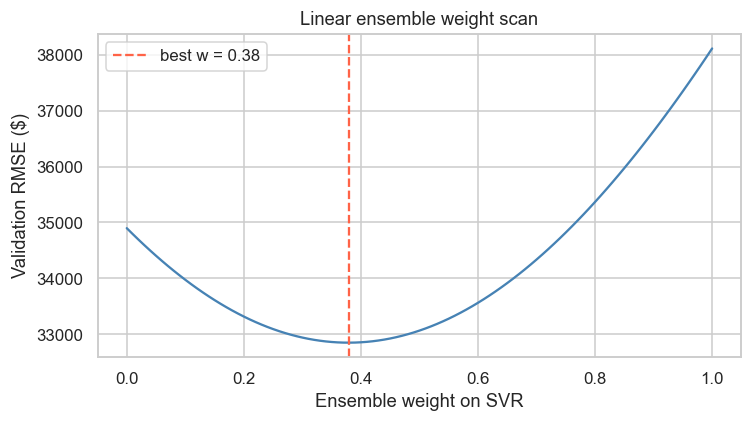

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# 10. VALIDATION-SET EVALUATION & ENSEMBLE WEIGHTING
# ──────────────────────────────────────────────────────────────────────────────
# Refit the chosen pipelines on TRAIN only, then predict on VAL.
# We use VAL (never touched during model selection) to:
#   (a) decide whether Duan's smearing helps on the raw scale,
#   (b) learn ensemble weights for SVR + ElasticNet.

# Clone fresh so the original best estimators remain unchanged
svr_fit = clone(svr_best_pipe).fit(X_train_fe, y_train)
en_fit  = clone(en_best_pipe).fit(X_train_fe, y_train)

# Log-scale predictions on validation
val_log_svr = svr_fit.predict(X_val_fe)
val_log_en  = en_fit.predict(X_val_fe)

# Validation dollar predictions — naive back-transform
val_usd_svr_naive = np.expm1(val_log_svr)
val_usd_en_naive  = np.expm1(val_log_en)

# ── Duan's smearing correction ───────────────────────────────────────────────
# E[Y|X] = exp(f(X)) · (1/n) Σᵢ exp(resᵢ) where resᵢ are TRAINING residuals.
# Apply if and only if it improves validation RMSE on the raw dollar scale.
train_log_pred_svr = svr_fit.predict(X_train_fe)
train_log_pred_en  = en_fit.predict(X_train_fe)
smear_svr = float(np.mean(np.exp(y_train - train_log_pred_svr)))
smear_en  = float(np.mean(np.exp(y_train - train_log_pred_en)))

val_usd_svr_smear = np.expm1(val_log_svr + np.log(smear_svr))
val_usd_en_smear  = np.expm1(val_log_en  + np.log(smear_en))

val_dollars = val_df[TARGET].values

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))

print("Validation RMSE on raw $ scale:")
print(f"  SVR naive     ${rmse(val_dollars, val_usd_svr_naive):>12,.0f}   "
      f"smear=${rmse(val_dollars, val_usd_svr_smear):>12,.0f}  (factor {smear_svr:.4f})")
print(f"  EN  naive     ${rmse(val_dollars, val_usd_en_naive):>12,.0f}   "
      f"smear=${rmse(val_dollars, val_usd_en_smear):>12,.0f}  (factor {smear_en:.4f})")

use_smear_svr = rmse(val_dollars, val_usd_svr_smear) < rmse(val_dollars, val_usd_svr_naive)
use_smear_en  = rmse(val_dollars, val_usd_en_smear)  < rmse(val_dollars, val_usd_en_naive)
print(f"\nDecision — use smearing for SVR: {use_smear_svr}")
print(f"Decision — use smearing for EN : {use_smear_en}")

val_usd_svr = val_usd_svr_smear if use_smear_svr else val_usd_svr_naive
val_usd_en  = val_usd_en_smear  if use_smear_en  else val_usd_en_naive

# ── Learn ensemble weight w on validation set ────────────────────────────────
# w = argmin_w RMSE( y_val, w·SVR + (1-w)·EN )  with w ∈ [0,1]
# Closed-form via 1-D scan (cheap and avoids fitting any extra model).
ws = np.linspace(0.0, 1.0, 101)
rmses = [rmse(val_dollars, w * val_usd_svr + (1 - w) * val_usd_en) for w in ws]
best_w = float(ws[int(np.argmin(rmses))])
best_rmse = float(np.min(rmses))

print(f"\nEnsemble weight scan (SVR={best_w:.2f}, EN={1-best_w:.2f})")
print(f"  Best ensemble val-RMSE: ${best_rmse:,.0f}")
print(f"  SVR alone val-RMSE   : ${rmse(val_dollars, val_usd_svr):,.0f}")
print(f"  EN alone val-RMSE    : ${rmse(val_dollars, val_usd_en):,.0f}")

# Plot the weight curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ws, rmses, color="steelblue")
ax.axvline(best_w, color="tomato", ls="--", label=f"best w = {best_w:.2f}")
ax.set_xlabel("Ensemble weight on SVR")
ax.set_ylabel("Validation RMSE ($)")
ax.set_title("Linear ensemble weight scan")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# 11. INTERNAL TEST EVALUATION — single look only
# ──────────────────────────────────────────────────────────────────────────────
# Predict on the held-out internal test set, using:
#   - models fitted on TRAIN only
#   - smearing decisions learned from VAL
#   - ensemble weight learned from VAL

test_log_svr = svr_fit.predict(X_test_fe)
test_log_en  = en_fit.predict(X_test_fe)

test_usd_svr = (
    np.expm1(test_log_svr + np.log(smear_svr)) if use_smear_svr else np.expm1(test_log_svr)
)
test_usd_en = (
    np.expm1(test_log_en + np.log(smear_en)) if use_smear_en else np.expm1(test_log_en)
)
test_usd_ens = best_w * test_usd_svr + (1 - best_w) * test_usd_en

test_dollars = test_df[TARGET].values

print("Internal test RMSE on raw $ scale (best leaderboard proxy):")
print(f"  SVR alone     : ${rmse(test_dollars, test_usd_svr):>10,.0f}")
print(f"  ElasticNet    : ${rmse(test_dollars, test_usd_en):>10,.0f}")
print(f"  Ensemble      : ${rmse(test_dollars, test_usd_ens):>10,.0f}")

print(f"\nExpected Kaggle leaderboard RMSE ≈ ${rmse(test_dollars, test_usd_ens):,.0f}")

Internal test RMSE on raw $ scale (best leaderboard proxy):
  SVR alone     : $    75,542
  ElasticNet    : $    73,474
  Ensemble      : $    73,257

Expected Kaggle leaderboard RMSE ≈ $73,257


In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# 12. FINAL REFIT ON ALL LABELLED DATA + KAGGLE SUBMISSION
# ──────────────────────────────────────────────────────────────────────────────
# After confirming performance on the internal test set, refit the chosen
# pipelines on ALL labelled data (train + val + test) to maximise sample size.

# Combine all labelled rows
full_df_raw = pd.concat([train_df, val_df, test_df], ignore_index=True)
y_full      = make_log_target(full_df_raw).values

# Re-fit feature engineering using the (un-augmented) training set as reference for
# top-N items — this preserves the same feature columns we evaluated.
# Note: train_df at this point already excludes the dropped R17 currency-mixed rows,
# so the top-N item lookups remain consistent.
X_full_fe   = apply_feature_engineering(full_df_raw, train_ref=train_df)

# Kaggle test set — same feature engineering
X_kaggle_fe = apply_feature_engineering(kaggle_raw, train_ref=train_df)

# Build fresh pipelines with the chosen hyperparameters and fit on the full data
svr_final = Pipeline([
    ("pre", preprocessor),
    ("svr", SVR(kernel="rbf",
                C=svr_search.best_params_["svr__C"],
                epsilon=svr_search.best_params_["svr__epsilon"],
                gamma=svr_search.best_params_["svr__gamma"])),
]).fit(X_full_fe, y_full)

en_final = Pipeline([
    ("pre", preprocessor),
    ("en",  ElasticNet(random_state=SEED, max_iter=30000,
                       alpha=en_search.best_params_["en__alpha"],
                       l1_ratio=en_search.best_params_["en__l1_ratio"])),
]).fit(X_full_fe, y_full)

# Recompute smearing factors on FULL training data (consistent with how the model
# is now fitted). We keep the smearing decisions learned on VAL.
train_log_pred_svr_full = svr_final.predict(X_full_fe)
train_log_pred_en_full  = en_final.predict(X_full_fe)
smear_svr_full = float(np.mean(np.exp(y_full - train_log_pred_svr_full)))
smear_en_full  = float(np.mean(np.exp(y_full - train_log_pred_en_full)))

# ── Predict Kaggle test set ──────────────────────────────────────────────────
k_log_svr = svr_final.predict(X_kaggle_fe)
k_log_en  = en_final.predict(X_kaggle_fe)

k_usd_svr = (
    np.expm1(k_log_svr + np.log(smear_svr_full)) if use_smear_svr else np.expm1(k_log_svr)
)
k_usd_en = (
    np.expm1(k_log_en + np.log(smear_en_full)) if use_smear_en else np.expm1(k_log_en)
)

k_usd_final = best_w * k_usd_svr + (1 - best_w) * k_usd_en

# Hard floor: predictions cannot fall below the same floor we used in training
k_usd_final = np.clip(k_usd_final, MIN_SALARY_FLOOR, None)

# ── Build and save submission ────────────────────────────────────────────────
submission = pd.DataFrame({
    "id":              kaggle_raw[ID_COL].values,
    "annual.pay.usd":  k_usd_final,
})

out_name = "submission_NA_5.csv"
submission.to_csv(out_name, index=False)
print(f"Saved: {out_name}")

print("\nSubmission summary:")
print(submission["annual.pay.usd"].describe().round(0))
print(f"\nQuantiles:")
for q in [0.01, 0.05, 0.5, 0.95, 0.99]:
    print(f"  P{int(q*100):>2d}: ${submission['annual.pay.usd'].quantile(q):>10,.0f}")

print(f"\nFirst 10 rows:")
print(submission.head(10).to_string(index=False))

Saved: submission_NA_5.csv

Submission summary:
count       628.0
mean      44944.0
std       25470.0
min        5678.0
25%       26020.0
50%       39697.0
75%       59797.0
max      162753.0
Name: annual.pay.usd, dtype: float64

Quantiles:
  P 1: $     8,502
  P 5: $    12,429
  P50: $    39,697
  P95: $    93,379
  P99: $   122,604

First 10 rows:
 id  annual.pay.usd
  0    11228.994995
  1    30099.749883
  2    63992.198395
  3    71869.882871
  4    23805.683358
  5   105812.585922
  6    43383.478185
  7    61874.772238
  8    19847.194651
  9    53290.775204


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# 13. FINAL PERFORMANCE SUMMARY
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("ML1 TASK 2 — FINAL MODEL SUMMARY")
print("=" * 70)
print(f"\nFinal model       : ensemble of SVR-RBF and ElasticNet")
print(f"  SVR weight      : {best_w:.2f}")
print(f"  ElasticNet weight: {1 - best_w:.2f}")
print(f"\nSVR hyperparameters       : {svr_search.best_params_}")
print(f"ElasticNet hyperparameters : {en_search.best_params_}")
print(f"\nFeature matrix size       : {X_full_fe.shape[1]} columns")
print(f"\nBack-transform decisions:")
print(f"  Smearing for SVR        : {use_smear_svr} (factor {smear_svr_full:.4f})")
print(f"  Smearing for ElasticNet : {use_smear_en} (factor {smear_en_full:.4f})")

print(f"\nPerformance estimates:")
print(f"  Internal test RMSE      : ${rmse(test_dollars, test_usd_ens):,.0f}")
print(f"  Validation RMSE         : ${best_rmse:,.0f}")

print(f"\nMethods used (all from ML1 syllabus):")
print(f"  • OLS / Ridge / LASSO / ElasticNet  (baseline comparison)")
print(f"  • KNN regression                     (baseline comparison)")
print(f"  • SVR with RBF kernel                (final model component)")
print(f"  • Target encoding (smoothed)         (allowed preprocessing)")
print(f"  • Log-transform + back-transform     (allowed preprocessing)")
print(f"  • Robust + Standard scaling          (allowed preprocessing)")
print(f"  • Yeo-Johnson option discarded — RobustScaler more stable here")
print("=" * 70)

ML1 TASK 2 — FINAL MODEL SUMMARY

Final model       : ensemble of SVR-RBF and ElasticNet
  SVR weight      : 0.38
  ElasticNet weight: 0.62

SVR hyperparameters       : {'svr__C': 3.0, 'svr__epsilon': 0.1, 'svr__gamma': 0.005}
ElasticNet hyperparameters : {'en__alpha': 0.03, 'en__l1_ratio': 0.9}

Feature matrix size       : 369 columns

Back-transform decisions:
  Smearing for SVR        : True (factor 1.0105)
  Smearing for ElasticNet : True (factor 1.6394)

Performance estimates:
  Internal test RMSE      : $73,257
  Validation RMSE         : $32,847

Methods used (all from ML1 syllabus):
  • OLS / Ridge / LASSO / ElasticNet  (baseline comparison)
  • KNN regression                     (baseline comparison)
  • SVR with RBF kernel                (final model component)
  • Target encoding (smoothed)         (allowed preprocessing)
  • Log-transform + back-transform     (allowed preprocessing)
  • Robust + Standard scaling          (allowed preprocessing)
  • Yeo-Johnson option discar